In [2]:
# Import Libraries
import os
import json
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
import seaborn as sns
import random
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

2025-02-07 17:06:45.007818: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/fatemi/Library/Python/3.8/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
# Load and Filter the Dataset

# Define paths
json_file_path = "photos.json"
image_folder = "./photos"

# Load JSON file
with open(json_file_path, "r") as file:
    data = [json.loads(line) for line in file]

# Convert to DataFrame
df = pd.DataFrame(data)

# Extract unique labels
unique_labels = df["label"].unique().tolist()
print("Unique Labels:", unique_labels)

# Add image path column
df["image_path"] = df["photo_id"].apply(lambda x: os.path.join(image_folder, x + ".jpg"))

# Initialize lists for valid and corrupted images
valid_images = []
corrupted_images = []

# Shuffle dataset for randomness
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check images and collect 500 valid ones
for _, row in df.iterrows():
    img_path = row["image_path"]
    try:
        img = cv2.imread(img_path)
        if img is None:
            raise ValueError("Corrupted image")
        valid_images.append(row)
        if len(valid_images) == 500:
            break
    except Exception:
        corrupted_images.append(img_path)

# Print corrupted images
if corrupted_images:
    print("\nCorrupted Images:")
    for img in corrupted_images:
        print(img)

# Display first few valid images
print("\nFirst 5 Valid Images:")
print(pd.DataFrame(valid_images).head())


Unique Labels: ['inside', 'outside', 'drink', 'food', 'menu']

First 5 Valid Images:
                 photo_id             business_id              caption  label  \
0  k_PSngRS22mSA1MypwrjPg  DzzVSYXadZ1_XgfGz_Loyw  Chocolate Croissant   food   
1  D_94KivwVgitkzFIgE_KcQ  Xdzir62WKlSzeu4PMQtlBA                        food   
2  Hf39P7_G_eRCqfVwvMDV6g  z0HzwNBmx_BgdiYI4hLk3g    Happy Anniversary  drink   
3  agxl4sABeRXwjLL506KMrQ  HzRSWmNxcEVQGrr1tun25w       Frozen Puccino   food   
4  7cZ0MREN2TwAAX4nnirQlA  aj0urA2r2WlqZKufeB5dpw  Double Cheeseburger   food   

                            image_path  
0  ./photos/k_PSngRS22mSA1MypwrjPg.jpg  
1  ./photos/D_94KivwVgitkzFIgE_KcQ.jpg  
2  ./photos/Hf39P7_G_eRCqfVwvMDV6g.jpg  
3  ./photos/agxl4sABeRXwjLL506KMrQ.jpg  
4  ./photos/7cZ0MREN2TwAAX4nnirQlA.jpg  


In [4]:
# Data Preprocessing

# Preprocess Images (with random selection)
def preprocess_images(image_folder, json_file_path, limit=100):
    image_files = os.listdir(image_folder)
    image_files = random.sample(image_files, limit)  # Randomly select 100 images

    images = []
    labels = []

    # Create a set of selected image files without the '.jpg' extension for fast lookup
    selected_image_ids = set([os.path.splitext(image_file)[0] for image_file in image_files])

    label_dict = {}

    # Open and read JSON file once, but only look for the labels of selected image files
    with open(json_file_path, 'r') as file:
        for line in file:
            image_data = json.loads(line)
            photo_id = image_data['photo_id']

            # Check if the current image is in the selected random images
            if photo_id in selected_image_ids:
                label_dict[photo_id] = image_data['label']

    # Now process the selected images
    for image_file in image_files:
        image_path = os.path.join(image_folder, image_file)
        
        try:
            # Read image
            image = cv2.imread(image_path)
            if image is None:
                print(f"Corrupted image: {image_file}")
                continue
            
            # Resize image
            image_resized = cv2.resize(image, (224, 224))  # Resizing to 224x224 for VGG models
            
            # Normalize pixel values to [0, 1]
            image_normalized = image_resized / 255.0
            images.append(image_normalized)

            # Extract label from the label dictionary (loaded JSON data)
            label = label_dict.get(os.path.splitext(image_file)[0], None)  # Default to None if no label found
            labels.append(label)
            
            # Debug print to check if the labels are correct
            print(f"Image: {image_file}, Label: {label}")
        
        except Exception as e:
            print(f"Error with image {image_file}: {e}")
    
    # Convert images list to numpy array
    images = np.array(images)
    labels = np.array(labels)
    
    return images, labels

# Path to the image folder and JSON file
image_folder = "./photos"
json_file_path = "photos.json"

# Preprocess the images
images, labels = preprocess_images(image_folder, json_file_path, limit=100)

# Encode the labels (convert string labels to numeric)
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

print(f"Processed {len(images)} images with {len(set(labels_encoded))} unique labels.")


Image: 8o8bK8tf4niIrvuxeLxgUg.jpg, Label: inside
Image: Qaf3EUJCwJ1Jg8lfbsY6Dw.jpg, Label: food
Image: lqIRAAEAPAA9HDYvxVoyzA.jpg, Label: inside
Image: mTnrGbMw3fzs2J2M0XGC8w.jpg, Label: food
Image: TcGIJ6jIAx93Ij6kGTO3dg.jpg, Label: food
Image: dgokfm3-ZvlXq1DDTYjApQ.jpg, Label: food
Image: PR2VUtipbrzANQQCDvyX3Q.jpg, Label: food
Image: 8eJ6tk5BfsjKP7FPRlFNsg.jpg, Label: outside
Image: 1P-KhLqVCnoIC8LwDTmhMg.jpg, Label: food
Image: chSaqOnfVXCTDQ_i7IsgXA.jpg, Label: inside
Image: 77k19E1uGmHQOeo2eAoGBg.jpg, Label: food
Image: EMKqUOCAsAc3JdNuX2jSlg.jpg, Label: outside
Image: JkiSK2h2G8VRhPDGTcdpIw.jpg, Label: inside
Image: 3bogzULrM8kmXInQ7SAK5Q.jpg, Label: food
Image: CKZdCg3M0bLvFtkxZaR8ag.jpg, Label: food
Image: XL4IxqryoJVvmstZzWHmPw.jpg, Label: drink
Image: ZuGUSCN33wXf5dCadN_s8A.jpg, Label: food
Image: BGIK8-6HduOHFqoU-jn2Jw.jpg, Label: food
Image: SnT2n2IE7966w5IJ4C565g.jpg, Label: food
Image: XFLrJpljrtEDh8KwXwQm0A.jpg, Label: inside
Image: 6_tn-wyEMsOOCHZItYrrZg.jpg, Label: f

In [5]:
# Model Building

# Load the pre-trained VGG16 model without the top (fully connected) layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Unfreeze some layers for fine-tuning
for layer in base_model.layers[-4:]:  # Unfreeze the last 4 layers
    layer.trainable = True

model = models.Sequential([
    base_model,  # Pre-trained VGG16 model
    layers.GlobalAveragePooling2D(),  # Pooling layer
    layers.Dense(256, activation='relu'),  # Fully connected layer
    layers.Dropout(0.5),  # Dropout for regularization
    layers.Dense(len(np.unique(labels_encoded)), activation='softmax')  # Output layer (correct class count)
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# Summary of the model
model.summary()

# Optionally, you can save the model architecture to a file
# model.save('fine_tuned_vgg_model.h5')


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d (  (None, 512)               0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 256)               131328    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 5)                 1285      
                                                                 
Total params: 14847301 (56.64 MB)
Trainable params: 14847301 (56.64 MB)
Non-trainable params: 0 (0.00 Byte)
______________

In [6]:
# Data Spliting

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(images, labels_encoded, test_size=0.2, random_state=42)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32
)


Epoch 1/5
3/3 [==============================] - 133s 38s/step - loss: 1.3788 - accuracy: 0.5000 - val_loss: 1.4158 - val_accuracy: 0.3500
Epoch 2/5
3/3 [==============================] - 128s 38s/step - loss: 1.0125 - accuracy: 0.6375 - val_loss: 1.1089 - val_accuracy: 0.5000
Epoch 3/5
3/3 [==============================] - 122s 38s/step - loss: 0.8970 - accuracy: 0.7125 - val_loss: 0.7129 - val_accuracy: 0.8500
Epoch 4/5
3/3 [==============================] - 123s 38s/step - loss: 0.5568 - accuracy: 0.8000 - val_loss: 0.6554 - val_accuracy: 0.8500
Epoch 5/5
3/3 [==============================] - 137s 42s/step - loss: 0.4915 - accuracy: 0.8500 - val_loss: 0.6446 - val_accuracy: 0.8500


1/1 [==============================] - 10s 10s/step


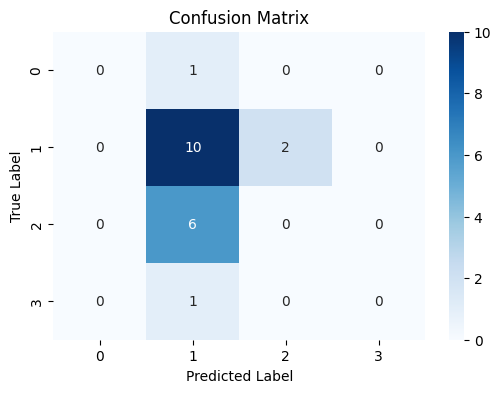


Label Mapping (Class Index → Label Name):
{0: 'drink', 1: 'food', 2: 'inside', 3: 'outside'}

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.56      0.83      0.67        12
           2       0.00      0.00      0.00         6
           3       0.00      0.00      0.00         1

    accuracy                           0.50        20
   macro avg       0.14      0.21      0.17        20
weighted avg       0.33      0.50      0.40        20



/Users/fatemi/Library/Python/3.8/lib/python/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/fatemi/Library/Python/3.8/lib/python/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/fatemi/Library/Python/3.8/lib/python/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


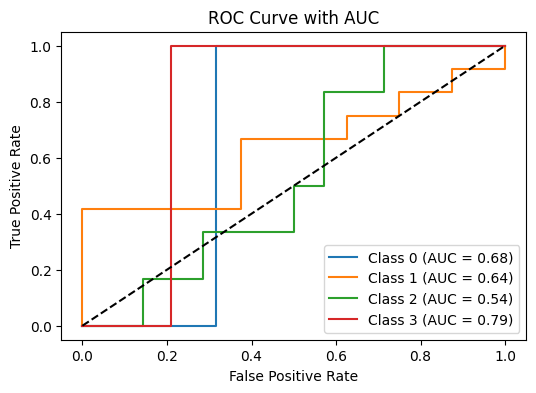

In [ ]:
# Model evaluation

# Get predictions
y_pred_probs = model.predict(X_val)  # Probabilities
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class labels

# Confusion Matrix
conf_matrix = confusion_matrix(y_val, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=set(labels_encoded), yticklabels=set(labels_encoded))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Label Mapping Dictionary
label_mapping = {idx: label for idx, label in enumerate(label_encoder.classes_)}
print("\nLabel Mapping (Class Index → Label Name):")
print(label_mapping)

# Classification Report
print("\nClassification Report:\n", classification_report(y_val, y_pred))

# Compute AUC for each class
plt.figure(figsize=(6, 4))
for i in range(len(set(labels_encoded))):
    fpr, tpr, _ = roc_curve(y_val == i, y_pred_probs[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], "k--")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with AUC")
plt.legend()
plt.show()


Epoch 1/5
3/3 [==============================] - 46s 14s/step - loss: 1.8104 - accuracy: 0.4875 - val_loss: 1.1245 - val_accuracy: 0.5500
Epoch 2/5
3/3 [==============================] - 41s 14s/step - loss: 2.0277 - accuracy: 0.4875 - val_loss: 1.1272 - val_accuracy: 0.5500
Epoch 3/5
3/3 [==============================] - 39s 13s/step - loss: 1.9904 - accuracy: 0.4875 - val_loss: 1.1289 - val_accuracy: 0.5000
Epoch 4/5
3/3 [==============================] - 40s 13s/step - loss: 2.1696 - accuracy: 0.3875 - val_loss: 1.1314 - val_accuracy: 0.5000
Epoch 5/5
1/1 [==============================] - 8s 8s/step
Confusion Matrix with Labels:
   0  1  2  3
0  0  0  1  0
1  0  9  3  0
2  0  5  1  0
3  0  1  0  0
AUC Score: 0.7626683897243107
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.60      0.75      0.67        12
           2       0.20      0.17      0.18         6
           3      

/Users/fatemi/Library/Python/3.8/lib/python/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/fatemi/Library/Python/3.8/lib/python/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/fatemi/Library/Python/3.8/lib/python/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


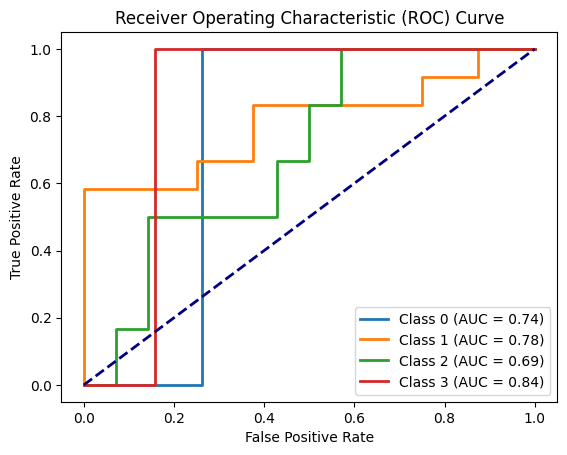

In [ ]:
# Approaches to Handle Class Imbalance --> Class Weights Adjustment

# New class weights to improve imbalance
class_weights = {0: 7.0, 1: 0.425, 2: 1.0, 3: 6.0}

# Compile the model with a smaller learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.00005)

# Compile model
model.compile(optimizer=optimizer, 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# Train the model with class weights
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    class_weight=class_weights
)

# Evaluate the model on the validation data
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_val, y_pred_classes)
cm_df = pd.DataFrame(conf_matrix, index=np.unique(y_val), columns=np.unique(y_val))
print("Confusion Matrix with Labels:")
print(cm_df)

# Calculate AUC Score
auc_score = roc_auc_score(y_val, y_pred, multi_class='ovr')
print(f"AUC Score: {auc_score}")

# Classification Report
print("Classification Report:")
print(classification_report(y_val, y_pred_classes, target_names=np.unique(y_val).astype(str)))

# Plot ROC AUC Curve
fpr = {}
tpr = {}
roc_auc = {}

# Calculate ROC curve for each class
for i in range(len(np.unique(y_val))):
    fpr[i], tpr[i], _ = roc_curve(y_val == i, y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure()
for i in range(len(np.unique(y_val))):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


Epoch 1/10
3/3 [==============================] - 48s 19s/step - loss: 4.3705 - accuracy: 0.4750 - val_loss: 1.1215 - val_accuracy: 0.6500
Epoch 2/10
3/3 [==============================] - 40s 13s/step - loss: 4.5342 - accuracy: 0.5500 - val_loss: 1.1205 - val_accuracy: 0.6500
Epoch 3/10
3/3 [==============================] - 40s 16s/step - loss: 4.1604 - accuracy: 0.4125 - val_loss: 1.1189 - val_accuracy: 0.6500
Epoch 4/10
3/3 [==============================] - 40s 14s/step - loss: 4.5024 - accuracy: 0.4500 - val_loss: 1.1197 - val_accuracy: 0.6000
Epoch 5/10
3/3 [==============================] - 40s 16s/step - loss: 3.7187 - accuracy: 0.4375 - val_loss: 1.1200 - val_accuracy: 0.6000
Epoch 6/10
1/1 [==============================] - 8s 8s/step
Confusion Matrix with Labels:
   0  1  2  3
0  0  0  1  0
1  0  7  5  0
2  0  0  6  0
3  0  1  0  0
AUC Score: 0.8057252506265664
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00   

/Users/fatemi/Library/Python/3.8/lib/python/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/fatemi/Library/Python/3.8/lib/python/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/fatemi/Library/Python/3.8/lib/python/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


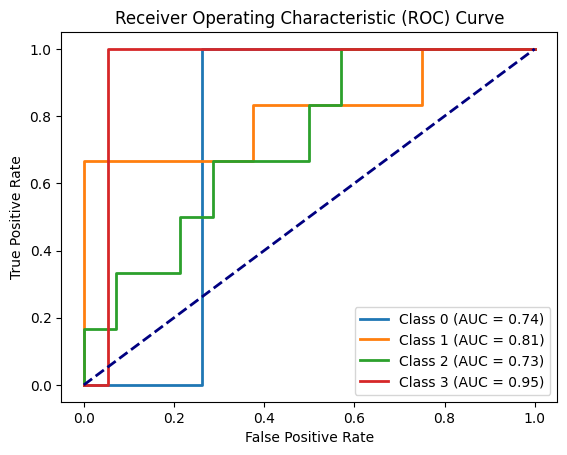

In [ ]:
# class weights, data augmentation, and early stopping for overfitting

# Class weights to address class imbalance
class_weights = {0: 10.0, 1: 1.0, 2: 5.0, 3: 10.0}  

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.00005)
model.compile(optimizer=optimizer, 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# Set up data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Fit the generator on your training data
datagen.fit(X_train)

# Set up EarlyStopping to monitor validation loss and stop early if necessary
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model with augmented data and class weights
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

# Evaluate the model on the validation data
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_val, y_pred_classes)
cm_df = pd.DataFrame(conf_matrix, index=np.unique(y_val), columns=np.unique(y_val))
print("Confusion Matrix with Labels:")
print(cm_df)

# Calculate AUC Score
auc_score = roc_auc_score(y_val, y_pred, multi_class='ovr')
print(f"AUC Score: {auc_score}")

# Classification Report
print("Classification Report:")
print(classification_report(y_val, y_pred_classes, target_names=np.unique(y_val).astype(str)))

# Plot ROC AUC Curve
fpr = {}
tpr = {}
roc_auc = {}

# Calculate ROC curve for each class
for i in range(len(np.unique(y_val))):
    fpr[i], tpr[i], _ = roc_curve(y_val == i, y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure()
for i in range(len(np.unique(y_val))):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
